In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
from tqdm import tqdm
import torch
import copy
from matplotlib.colors import hsv_to_rgb
import pandas as pd
import matplotlib as mpl
from matplotlib.widgets import LassoSelector
from matplotlib.path import Path
from sklearn.decomposition import PCA
from matplotlib.widgets import Slider
from scipy.ndimage import gaussian_filter1d
from scipy.stats import gaussian_kde
import bisect

In [95]:
#data = pd.read_csv("\\\\NAS_LOCCO\\Amaury\\DATA\\4polar_data_raw\\2026_02_02_SLB_1um\\SM_tres_haut\\Calib_Polar_2026-02-02\\images\\RAW_DATA\\image_Pos0.ome_results_fr1to15000_method=Propagation matrix_box-method=Fixed_box5.csv")
#data = pd.read_csv("\\\\NAS_LOCCO\\Amaury\\DATA\\4polar_data_raw\\2026_02_20_sperm_souris\\sample1\\sm1\\Calib_Polar_2026-02-20\\images\\RAW_DATA\\image_Pos0.ome_results_fr1to10000_method=Propagation matrix_box-method=Fixed_box5.csv", delimiter=',')
#data = pd.read_csv("\\\\NAS_LOCCO\\Amaury\\DATA\\4polar_data_raw\\2026_02_20_sperm_souris\\sample1\\sm2\\Calib_Polar_2026-02-20\\images\\RAW_DATA\\image_Pos0.ome_results_fr1to10000_method=Propagation matrix_box-method=Fixed_box5.csv", delimiter=',')
data = pd.read_csv("\\\\NAS_LOCCO\\Amaury\\DATA\\4polar_data_raw\\2026_02_20_sperm_souris\\sample1\\sm4\\Calib_Polar_2026-02-20\\images\\RAW_DATA\\image_Pos0.ome_results_fr1to30000_method=Propagation matrix_box-method=Fixed_box5.csv", delimiter=',')
#data = pd.read_csv("\\\\NAS_LOCCO\\Amaury\\DATA\\4polar_data_raw\\2026_03_13_sperm_souris\\sample2\\sm\\Calib_Polar_2026-03-13\\images\\RAW_DATA\\image_Pos0.ome_results_fr1to40000_method=Propagation matrix_box-method=Fixed_box5.csv", delimiter=',')
#data = pd.read_csv("\\\\NAS_LOCCO\\Amaury\\DATA\\4polar_data_raw\\2026_02_19_sperm_souris_lame_PBS\\sample3\\sm1\\Calib_Polar_2026-02-19\\images\\RAW_DATA\\image_Pos0.ome_results_fr1to5000_method=Propagation matrix_box-method=Fixed_box5.csv", delimiter=',')
frame = data['frame'].to_numpy()
x = data['x [nm]'].to_numpy()
y = data['y [nm]'].to_numpy()
z = data['z [nm]'].to_numpy()
rho = (data['rho'].to_numpy()+60)%180
delta = data['delta'].to_numpy()
N_photons = data['intensity [a.u.]'].to_numpy()

In [96]:
plt.rcParams['figure.figsize'] = [8,3]
hist = plt.hist(z, bins=80)
plt.xlabel('z')
plt.ylabel('Occurences')

Text(0, 0.5, 'Occurences')

In [97]:
mask1= (delta<120) & (z<1000) & (z>-100)

# Drift correction

In [98]:
%matplotlib qt
plt.rcParams['figure.figsize'] = [15,15]
fig = plt.figure()
ax = fig.add_subplot()
vals = frame
sc = ax.scatter(x , y , c=vals , cmap='coolwarm', s=1)
ax.axis('equal')
cb = plt.colorbar(sc)
cb.ax.invert_yaxis()
points = np.column_stack((x, y))
mask = np.zeros(len(x), dtype=bool)

def onselect(verts):
    global mask
    path = Path(verts)
    mask = path.contains_points(points) 
    print(mask)

lasso = LassoSelector(ax, onselect)
plt.show()

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


[False  True  True ... False False False]


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


In [99]:
def mean_x_per_20_frames(x, frame, window=20):

    bins = (frame // window).astype(int)
    n_bins = bins.max() + 1

    sum_x = np.bincount(bins, weights=x, minlength=n_bins)
    count = np.bincount(bins, minlength=n_bins)

    mean_x = np.zeros(n_bins)

    nonzero = count > 0
    mean_x[nonzero] = sum_x[nonzero] / count[nonzero]

    mean_x[~nonzero] = np.nan  # only real empty bins

    return mean_x

In [100]:
mean_x = mean_x_per_20_frames(x[mask], frame[mask], 200)
mean_y = mean_x_per_20_frames(y[mask], frame[mask], 200)

In [101]:
for i in range(len(mean_x)):
    if np.isnan(mean_x[i]):
        mean_x[i] = (mean_x[i-1]+mean_x[i+1])/2
        mean_y[i] = (mean_y[i-1]+mean_y[i+1])/2

In [102]:
np.isnan(mean_x).any()
np.isnan(mean_y).any()

False

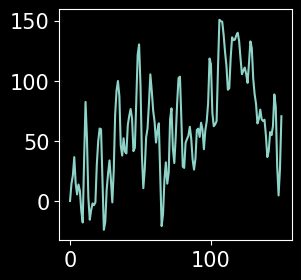

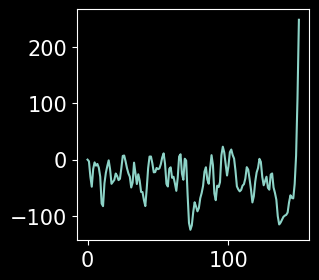

In [103]:
%matplotlib inline
plt.rcParams['figure.figsize'] = [3,3]
xcorr = gaussian_filter1d(mean_x, 1)
xcorr = xcorr-xcorr[0]
plt.plot(xcorr)
plt.show()
ycorr = gaussian_filter1d(mean_y, 1)
ycorr = ycorr-ycorr[0]
plt.plot(ycorr)

In [104]:
frame_bins = np.linspace(0, np.max(frame), len(xcorr)).astype(int)

In [105]:
for ind, frame_ in tqdm(enumerate(frame)):
    idx = bisect.bisect_left(frame_bins, frame_)
    #print(frame_, idx, frame_bins[idx-1])
    x[ind]-=xcorr[idx-1]
    y[ind]-=ycorr[idx-1]
    #print(ind, frame_, x[ind], y[ind], xcorr[idx-1]*0.45, ycorr[idx-1]*0.6)

514722it [00:00, 531613.25it/s]


In [106]:
%matplotlib qt
plt.rcParams['figure.figsize'] = [15,15]
fig = plt.figure()
ax = fig.add_subplot()
vals = frame
sc = ax.scatter(x , y , c=vals , cmap='coolwarm', s=0.1)
ax.axis('equal')
cb = plt.colorbar(sc)
cb.ax.invert_yaxis()

# Density

In [107]:
%matplotlib qt

fig, ax = plt.subplots(figsize=(8, 8))

sc = ax.scatter(x[mask1], y[mask1], s=0.1, c=delta[mask1])
ax.set_title("Lasso select regions (close window to finish)")
ax.axis('equal')

points = np.column_stack((x, y))

# store all selections
masks = []

# -----------------------------
# CALLBACK FUNCTION
# -----------------------------
def onselect(verts):
    path = Path(verts)

    # selection mask
    mask = path.contains_points(points) & mask1

    if np.sum(mask) < 10:
        print("Selection too small")
        return

    masks.append(mask)
    print(f"Selection stored: {len(masks)} (points: {np.sum(mask)})")

    # -----------------------------
    # PCA + density
    # -----------------------------
    XY = np.column_stack((x[mask], y[mask]))

    pca = PCA(n_components=1)
    principal_coord = pca.fit_transform(XY).flatten()

    # KDE density
    kde = gaussian_kde(principal_coord)
    s_eval = np.linspace(principal_coord.min(), principal_coord.max(), 500)
    density = kde(s_eval)
    density = density/np.max(density)

    # -----------------------------
    # Plot results
    # -----------------------------
    fig2, ax2 = plt.subplots(1, 2, figsize=(10, 4))

    # (1) scatter + principal axis
    mean = XY.mean(axis=0)
    direction = pca.components_[0]

    line = np.array([
        mean - 100 * direction,
        mean + 100 * direction
    ])

    ax2[0].scatter(XY[:, 0], XY[:, 1], s=1)
    ax2[0].plot(line[:, 0], line[:, 1], 'r')
    ax2[0].set_title("Selection + principal axis")
    ax2[0].axis('equal')

    # (2) density plot
    ax2[1].plot(s_eval, density)
    ax2[1].set_title("Density along principal axis")
    ax2[1].set_xlabel("Position (nm)")
    ax2[1].set_ylabel("Renormalized density")

    plt.tight_layout()
    plt.show()


# -----------------------------
# LASSO TOOL
# -----------------------------
lasso = LassoSelector(ax, onselect)

plt.show()

# -----------------------------
# AFTER CLOSING WINDOW
# -----------------------------
print(f"\nTotal selections: {len(masks)}")


Total selections: 0
Selection stored: 1 (points: 10531)


# rho

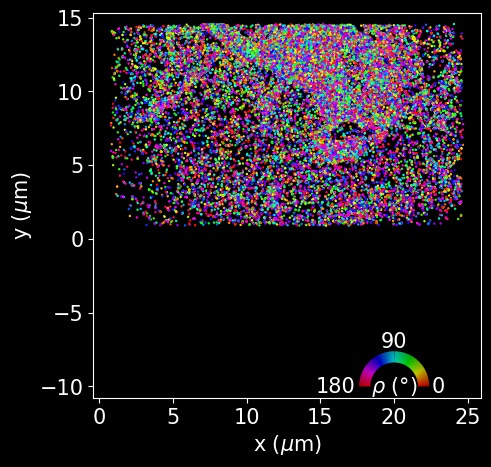

In [108]:
%matplotlib inline
plt.rcParams['figure.figsize'] = [5, 5]
plt.rcParams.update({'font.size': 15})
hues = rho[mask1] / 180.0
hsv_colors = np.stack((hues, np.ones_like(hues), np.ones_like(hues)), axis=1)
rgb_colors = hsv_to_rgb(hsv_colors)
plt.scatter(x[mask1]/1000, y[mask1]/1000, c=rgb_colors, s=0.5)
plt.axis('equal')
#plt.xlim((10000, 22500))
#plt.ylim((2200, 14000))
plt.xlabel('x ($\\mu$m)')
plt.ylabel('y ($\\mu$m)')

# Half-circle colorbar rotated 90° clockwise
center_x, center_y = 20, -10
radius = 2
angles = np.linspace(0, np.pi, 200)  # rotated arc
for i in range(len(angles)-1):
    theta1, theta2 = angles[i], angles[i+1]
    hue = (np.degrees(theta1)) / 180.0  # Map to 0-1 range
    color = hsv_to_rgb([hue, 1, 1])
    arc_x = [center_x + radius * np.cos(theta1), center_x + radius * np.cos(theta2)]
    arc_y = [center_y + radius * np.sin(theta1), center_y + radius * np.sin(theta2)]
    plt.plot(arc_x, arc_y, color=color, lw=8, solid_capstyle='butt')

# Tick labels with offset
tick_angles = [180, 90, 0]  # Corresponding to hue range
label_offset = [-6.,1, -5]
plt.text(center_x, center_y, "$\\rho$ ($\\degree$)", ha='center', va='center', fontsize=15)
for i, ang in enumerate(tick_angles):
    rad = np.radians(ang)
    tx = center_x + (radius + label_offset[i]) * np.cos(np.pi-rad)
    ty = center_y + (radius + label_offset[i]) * np.sin(np.pi-rad)
    plt.text(tx, ty, f"{(ang)}", ha='center', va='center', fontsize=15)
#plt.xlim((6, 13.5))
#plt.ylim((12.8, 18.5))
#plt.savefig("imE.png", format="png")
plt.show()

In [ ]:
hh = plt.hist(delta, bins=100)
print(len(delta))

In [ ]:
hh = plt.hist(rho[mask1], bins=1000)

# Select ROI rho

In [113]:
%matplotlib qt
plt.rcParams['figure.figsize'] = [15,15]
fig = plt.figure()
ax = fig.add_subplot()
norm = mpl.colors.Normalize(vmin=0., vmax=180.)
vals = rho[mask1]
sc = ax.scatter(x[mask1] , y[mask1], c=vals , cmap='hsv', norm=norm, s=0.1)
ax.axis('equal')
cb = plt.colorbar(sc)
cb.ax.invert_yaxis()
points = np.column_stack((x, y))
mask = np.zeros(len(x), dtype=bool)

def onselect(verts):
    global mask
    path = Path(verts)
    mask = path.contains_points(points) & mask1
    print(mask)

lasso = LassoSelector(ax, onselect)
plt.show()

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


[False False False ... False False False]


In [114]:
angles = np.deg2rad(rho[mask])

bins = 18
counts, bin_edges = np.histogram(angles, bins=bins, density=False)

bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
width = bin_edges[1] - bin_edges[0]

# Duplicate with π shift
bin_centers_full = np.concatenate([bin_centers, bin_centers + np.pi])
counts_full = np.concatenate([counts, counts])

# ----- Figure -----
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection='polar')

ax.bar(bin_centers_full, counts_full, width=width, alpha=0.8)

# 🔥 Set radial ticks = counts
rmax = counts_full.max()

rticks = np.linspace(0, rmax, 5)  # 5 circular grid lines
ax.set_rticks(rticks)
ax.set_yticklabels([f"{int(r)}" for r in rticks])

# Optional orientation
ax.set_theta_zero_location("E")
#ax.set_theta_direction(-1)

plt.show()

In [ ]:
%matplotlib qt
plt.rcParams['figure.figsize'] = [15,15]
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
norm = mpl.colors.Normalize(vmin=0., vmax=180.)
vals = rho[mask]
sc = ax.scatter(x[mask] , y[mask], z[mask], c=vals , cmap='hsv', norm=norm, s=0.1)
ax.axis('equal')
cb = plt.colorbar(sc)

# Correlation function

In [ ]:
len(x[mask])

In [ ]:
random_idx = np.random.choice(np.flatnonzero(mask), size=30000, replace=False)

In [ ]:
list_cos = np.zeros((30000,100))
distance = np.zeros((30000,100))
for i, ind in tqdm(enumerate(random_idx)):
    r_max=1000
    submask = mask & (((x-x[ind])**2+(y-y[ind])**2 +(z-z[ind])**2 <r_max**2)) # 
    random_sub_idx = np.random.choice(np.flatnonzero(submask), size=10, replace=False)
    for k, ind2 in enumerate(random_sub_idx):
        list_cos[i][k] = np.cos(rho[ind]-rho[ind2])
        distance[i][k] = np.sqrt((x[ind2]-x[ind])**2+(y[ind2]-y[ind])**2+(z[ind2]-z[ind])**2) # 

In [ ]:
r_bins = np.linspace(1, r_max, 100)

In [ ]:
corr = []
uncertainty = []

for j in range(len(r_bins)-1):
    r_start = r_bins[j]
    r_end = r_bins[j+1]
    
    mask_bin = (distance >= r_start) & (distance < r_end)
    
    values = list_cos[mask_bin]
    
    if len(values) == 0:
        # interpolate from neighbors or set 0
        mean_val = 0
    else:
        mean_val = np.mean(values**1)
    
    corr.append(mean_val)
    uncertainty.append(1/np.sqrt(np.sum(mask_bin)))
corr = np.array(corr)

In [ ]:
plt.rcParams['figure.figsize'] = [10,9]
r_centers = (r_bins[:-1] + r_bins[1:]) / 2
plt.plot(r_centers, gaussian_filter1d(corr, 3))
plt.plot(r_centers, uncertainty)
plt.xlabel('distance (nm)')
plt.ylabel('$<cos(\\Delta \\rho)>$')
#plt.xlim((0,300))
plt.grid()

In [ ]:
%matplotlib qt
plt.scatter(x[mask], y[mask], c=frame[mask], s=1)